# DAM304 Practical 3: Build and Understand the Core Attention Mechanism

This notebook implements the core components of transformer attention from scratch:
- **Task 1**: Scaled Dot-Product Attention using NumPy
- **Task 2**: Scaled Dot-Product Attention using PyTorch  
- **Task 3**: Multi-Head Attention
- **Task 4**: Complete Transformer Block with Visualization

By the end, you'll understand how tokens communicate through attention and visualize attention patterns.

## Section 1: Environment Setup and Imports

In [1]:
# Install required libraries (if needed)
import subprocess
import sys

try:
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "numpy", "matplotlib"])
    import torch
    import numpy as np
    import matplotlib.pyplot as plt

print("Libraries installed successfully!")

Libraries installed successfully!


In [2]:
# Import all required libraries
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

All imports successful!
PyTorch version: 2.11.0
NumPy version: 2.4.4


## Task 1: Scaled Dot-Product Attention (NumPy)

Implement the full attention computation using NumPy only. This forces us to reason carefully about matrix dimensions.

**Formula**: Attention(Q, K, V) = softmax(Q @ K^T / sqrt(d_k)) @ V

In [ ]:
def scaled_dot_product_attention_np(Q, K, V, mask=None):
    """
    NumPy implementation of scaled dot-product attention.
    
    Args:
        Q : np.ndarray, shape (n, d_k) - Query matrix
        K : np.ndarray, shape (n, d_k) - Key matrix
        V : np.ndarray, shape (n, d_v) - Value matrix
        mask: np.ndarray or None, shape (n, n), boolean.
              True = keep, False = mask (set to -1e9)
    
    Returns:
        output : np.ndarray, shape (n, d_v) - Attention output
        weights : np.ndarray, shape (n, n) - Attention probabilities
    """
    d_k = Q.shape[-1]
    
    # Step 1: Compute raw attention scores: Q @ K^T
    scores = Q @ K.T  # Shape: (n, n) which is 4x4 (4, 4)    
    # Step 2: Scale by sqrt(d_k)
    scores = scores / np.sqrt(d_k)
    
    # Step 3: Apply mask if provided
    if mask is not None:
        scores = np.where(mask, scores, -1e9)
    
    # Step 4: Apply softmax with numerical stability
    # Subtract row maximum before exp to prevent overflow/underflow
    scores_max = np.max(scores, axis=-1, keepdims=True)
    exp_scores = np.exp(scores - scores_max)
    weights = exp_scores / np.sum(exp_scores, axis=-1, keepdims=True)  # Shape: (n, n)
    
    # Step 5: Compute output: weights @ V
    output = weights @ V  # Shape: (n, d_v)
    
    return output, weights

# Test with provided inputs
np.random.seed(42)
n, d_k, d_v = 4, 8, 8
Q = np.random.randn(n, d_k)
K = np.random.randn(n, d_k)
V = np.random.randn(n, d_v)

print("=" * 60)
print("TASK 1: NumPy Attention (No Mask)")
print("=" * 60)

output, weights = scaled_dot_product_attention_np(Q, K, V)
print(f"Output shape: {output.shape}")
print(f"Weights shape: {weights.shape}")
print(f"\nAttention Weight Matrix (4x4):")
print(weights)
print(f"\nRow sums (should all be 1.0): {weights.sum(axis=-1)}")
print(f"All rows sum to 1.0? {np.allclose(weights.sum(axis=-1), np.ones(n))}")

TASK 1: NumPy Attention (No Mask)
Output shape: (4, 8)
Weights shape: (4, 4)

Attention Weight Matrix (4x4):
[[0.08431243 0.25513027 0.51521078 0.14534652]
 [0.64059204 0.1332861  0.01664257 0.2094793 ]
 [0.47006414 0.08789379 0.11121405 0.33082801]
 [0.17794451 0.49185018 0.20052305 0.12968226]]

Row sums (should all be 1.0): [1. 1. 1. 1.]
All rows sum to 1.0? True


In [4]:
print("\n" + "=" * 60)
print("TASK 1: NumPy Attention (With Causal Mask)")
print("=" * 60)

# Create causal mask: lower triangular (True below and on diagonal, False above)
causal_mask = np.tril(np.ones((n, n)), k=0).astype(bool)
print(f"Causal mask (1=keep, 0=mask):\n{causal_mask.astype(int)}")

output_causal, weights_causal = scaled_dot_product_attention_np(Q, K, V, mask=causal_mask)
print(f"\nAttention Weight Matrix with Causal Mask:")
print(weights_causal)
print(f"\nRow sums with causal mask: {weights_causal.sum(axis=-1)}")
print(f"Upper triangle all zeros? {np.allclose(weights_causal[np.triu_indices(n, k=1)], 0.0)}")


TASK 1: NumPy Attention (With Causal Mask)
Causal mask (1=keep, 0=mask):
[[1 0 0 0]
 [1 1 0 0]
 [1 1 1 0]
 [1 1 1 1]]

Attention Weight Matrix with Causal Mask:
[[1.         0.         0.         0.        ]
 [0.82776862 0.17223138 0.         0.        ]
 [0.7024564  0.13134709 0.16619652 0.        ]
 [0.17794451 0.49185018 0.20052305 0.12968226]]

Row sums with causal mask: [1. 1. 1. 1.]
Upper triangle all zeros? True


## Task 2: Scaled Dot-Product Attention (PyTorch)

Now implement the same attention mechanism as a trainable PyTorch nn.Module with learned weight matrices W_Q, W_K, W_V.

In [5]:
class ScaledDotProductAttention(nn.Module):
    """
    Learnable scaled dot-product attention with optional causal mask.
    
    Args:
        d_model : int — full embedding dimension
        d_k : int — query/key projection dimension
        d_v : int — value projection dimension
        dropout : float — dropout probability (default 0.0)
    """
    
    def __init__(self, d_model, d_k, d_v, dropout=0.0):
        super().__init__()
        self.d_k = d_k
        
        # Learned projection matrices
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_v, bias=False)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, causal=False):
        """
        Args:
            x : Tensor, shape (B, n, d_model) - Input sequence
            causal : bool — if True, apply causal mask
        
        Returns:
            output : Tensor, shape (B, n, d_v) - Attention output
            weights : Tensor, shape (B, n, n) - Attention weights
        """
        B, n, d_model = x.shape
        
        # Step 1: Project through learned weight matrices
        Q = self.W_Q(x)  # (B, n, d_k)
        K = self.W_K(x)  # (B, n, d_k)
        V = self.W_V(x)  # (B, n, d_v)
        
        # Step 2: Compute raw scores: Q @ K^T
        scores = torch.matmul(Q, K.transpose(-2, -1))  # (B, n, n)
        
        # Step 3: Scale by 1 / sqrt(d_k)
        scores = scores / math.sqrt(self.d_k)
        
        # Step 4: Apply causal mask if needed
        if causal:
            mask = torch.tril(torch.ones(n, n, device=x.device)).bool()
            scores = scores.masked_fill(~mask, float('-inf'))
        
        # Step 5: Apply softmax
        weights = F.softmax(scores, dim=-1)  # (B, n, n)
        
        # Step 6: Apply dropout
        weights = self.dropout(weights)
        
        # Step 7: Compute output: weights @ V
        output = torch.matmul(weights, V)  # (B, n, d_v)
        
        return output, weights

# Test
torch.manual_seed(42)
B, n, d_model = 2, 6, 64
d_k = d_v = 64
x = torch.randn(B, n, d_model)
attn = ScaledDotProductAttention(d_model, d_k, d_v)

print("\n" + "=" * 60)
print("TASK 2: PyTorch Attention (No Causal Mask)")
print("=" * 60)

output, weights = attn(x, causal=False)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Weights shape: {weights.shape}")
print(f"Weights[0] row sums: {weights[0].sum(dim=-1)}")
print(f"All rows sum to ~1.0? {torch.allclose(weights.sum(dim=-1), torch.ones(B, n), atol=1e-5)}")


TASK 2: PyTorch Attention (No Causal Mask)
Input shape: torch.Size([2, 6, 64])
Output shape: torch.Size([2, 6, 64])
Weights shape: torch.Size([2, 6, 6])
Weights[0] row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)
All rows sum to ~1.0? True


In [7]:
print("\n" + "=" * 60)
print("TASK 2: PyTorch Attention (With Causal Mask)")
print("=" * 60)

output_causal, weights_causal = attn(x, causal=True)
print(f"Output shape: {output_causal.shape}")
print(f"Weights shape: {weights_causal.shape}")
print(f"\nFirst batch, first head attention pattern:")
print(weights_causal[0])
print(f"\nFirst position weights (should attend only to itself): {weights_causal[0, 0, :]}")

# Extract upper triangle to verify causal masking
mask_upper = torch.triu_indices(n, n, offset=1)
upper_triangle_vals = weights_causal[0, mask_upper[0], mask_upper[1]]
print(f"Upper triangle all zero/NaN? {torch.all((upper_triangle_vals == 0) | torch.isnan(upper_triangle_vals))}")


TASK 2: PyTorch Attention (With Causal Mask)
Output shape: torch.Size([2, 6, 64])
Weights shape: torch.Size([2, 6, 6])

First batch, first head attention pattern:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6130, 0.3870, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3004, 0.2110, 0.4886, 0.0000, 0.0000, 0.0000],
        [0.2015, 0.3219, 0.2550, 0.2215, 0.0000, 0.0000],
        [0.2958, 0.2160, 0.1495, 0.1643, 0.1744, 0.0000],
        [0.1485, 0.1527, 0.2348, 0.1520, 0.1822, 0.1298]],
       grad_fn=<SelectBackward0>)

First position weights (should attend only to itself): tensor([1., 0., 0., 0., 0., 0.], grad_fn=<SelectBackward0>)
Upper triangle all zero/NaN? True


## Task 3: Multi-Head Attention

Implement multi-head attention by splitting embeddings into h parallel heads of dimension d_k = d_model / h.
Each head computes attention independently, then results are concatenated and projected to d_model.

In [8]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head attention as described in Vaswani et al. (2017).
    
    Args:
        d_model : int — full embedding dimension (e.g. 512)
        num_heads : int — number of attention heads (e.g. 8)
        dropout : float — dropout probability
        
    Constraint: d_model must be divisible by num_heads.
    """
    
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension of each head
        
        # Four linear layers: one each for Q, K, V, and output projection
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        
        self.dropout = nn.Dropout(dropout)
    
    def split_heads(self, x, B, n):
        """
        Reshape (B, n, d_model) -> (B, num_heads, n, d_k)
        so each head attends to its own d_k-dimensional slice.
        """
        x = x.view(B, n, self.num_heads, self.d_k)
        return x.transpose(1, 2)  # (B, num_heads, n, d_k)
    
    def forward(self, x, causal=False):
        """
        Args:
            x : Tensor, shape (B, n, d_model)
            causal : bool — if True, apply causal mask
        
        Returns:
            output : Tensor, shape (B, n, d_model)
            weights : Tensor, shape (B, num_heads, n, n)
        """
        B, n, d_model = x.shape
        
        # Step 1: Project Q, K, V through learned weight matrices
        Q = self.W_Q(x)  # (B, n, d_model)
        K = self.W_K(x)  # (B, n, d_model)
        V = self.W_V(x)  # (B, n, d_model)
        
        # Step 2: Split into multiple heads
        Q = self.split_heads(Q, B, n)  # (B, num_heads, n, d_k)
        K = self.split_heads(K, B, n)  # (B, num_heads, n, d_k)
        V = self.split_heads(V, B, n)  # (B, num_heads, n, d_k)
        
        # Step 3: Compute attention scores for each head
        scores = torch.matmul(Q, K.transpose(-2, -1))  # (B, num_heads, n, n)
        scores = scores / math.sqrt(self.d_k)
        
        # Step 4: Apply causal mask if needed (must be broadcastable to (B, h, n, n))
        if causal:
            mask = torch.tril(torch.ones(n, n, device=x.device)).bool()
            mask = mask.unsqueeze(0).unsqueeze(0)  # (1, 1, n, n)
            scores = scores.masked_fill(~mask, float('-inf'))
        
        # Step 5: Apply softmax and dropout
        weights = F.softmax(scores, dim=-1)  # (B, num_heads, n, n)
        weights = self.dropout(weights)
        
        # Step 6: Compute context: weights @ V
        context = torch.matmul(weights, V)  # (B, num_heads, n, d_k)
        
        # Step 7: Concatenate heads back together
        context = context.transpose(1, 2)  # (B, n, num_heads, d_k)
        context = context.contiguous().view(B, n, d_model)  # (B, n, d_model)
        
        # Step 8: Apply output projection
        output = self.W_O(context)  # (B, n, d_model)
        
        return output, weights

# Test
torch.manual_seed(42)
B, n, d_model, h = 2, 10, 512, 8
x = torch.randn(B, n, d_model)
mha = MultiHeadAttention(d_model, num_heads=h)

print("\n" + "=" * 60)
print("TASK 3: Multi-Head Attention")
print("=" * 60)

output, weights = mha(x, causal=False)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Weights shape: {weights.shape} (Batch, Heads, Seq, Seq)")
print(f"Output shape matches input? {output.shape == x.shape}")

# Count parameters
param_count = sum(p.numel() for p in mha.parameters())
print(f"\nNumber of trainable parameters: {param_count:,}")
print(f"Expected (~1,048,576 for 512x512): {param_count == 4 * 262144}")


TASK 3: Multi-Head Attention
Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])
Weights shape: torch.Size([2, 8, 10, 10]) (Batch, Heads, Seq, Seq)
Output shape matches input? True

Number of trainable parameters: 1,048,576
Expected (~1,048,576 for 512x512): True


In [9]:
print("\n" + "=" * 60)
print("TASK 3: Multi-Head Attention (With Causal Mask)")
print("=" * 60)

output_causal, weights_causal = mha(x, causal=True)
print(f"Output shape: {output_causal.shape}")
print(f"Weights shape: {weights_causal.shape}")

# Verify causal masking
mask_upper = torch.triu_indices(n, n, offset=1)
upper_triangle_vals = weights_causal[:, :, mask_upper[0], mask_upper[1]]
print(f"Upper triangle contains only zeros/NaN? {torch.all((upper_triangle_vals == 0) | torch.isnan(upper_triangle_vals))}")
print(f"Sample head 0 weights (should show causal pattern):\n{weights_causal[0, 0][:3, :3]}")


TASK 3: Multi-Head Attention (With Causal Mask)
Output shape: torch.Size([2, 10, 512])
Weights shape: torch.Size([2, 8, 10, 10])
Upper triangle contains only zeros/NaN? True
Sample head 0 weights (should show causal pattern):
tensor([[1.0000, 0.0000, 0.0000],
        [0.6182, 0.3818, 0.0000],
        [0.1842, 0.5740, 0.2418]], grad_fn=<SliceBackward0>)


## Task 4: Transformer Block and Attention Visualization

Assemble a complete transformer layer by combining:
- Multi-head attention
- Layer normalization (Pre-LN variant)
- Feed-forward network
- Residual connections

Then visualize attention patterns with a heatmap.

In [10]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network: FFN(x) = GELU(xW1 + b1)W2 + b2"""
    
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.act = nn.GELU()
    
    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))


class TransformerBlock(nn.Module):
    """
    One transformer layer (Pre-LN variant):
    x -> LayerNorm -> MultiHeadAttention -> residual -> LayerNorm -> FFN -> residual
    
    Args:
        d_model : int
        num_heads : int
        d_ff : int — inner dimension of FFN (typically 4 * d_model)
        dropout : float
    """
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff)
        self.drop = nn.Dropout(dropout)
    
    def forward(self, x, causal=False):
        """
        Args:
            x : Tensor, shape (B, n, d_model)
            causal : bool
        
        Returns:
            output : Tensor, shape (B, n, d_model)
            weights : Tensor, shape (B, num_heads, n, n) - Attention weights
        """
        
        # Step 1a: Apply layer norm and attention
        attn_out, weights = self.attn(self.norm1(x), causal=causal)
        
        # Step 1b: Residual connection after dropout
        x = x + self.drop(attn_out)
        
        # Step 2: Apply layer norm and feed-forward
        ff_out = self.ff(self.norm2(x))
        
        # Step 3: Residual connection
        x = x + self.drop(ff_out)
        
        return x, weights


# Test the TransformerBlock
torch.manual_seed(42)
d_model, num_heads, d_ff = 256, 8, 1024
block = TransformerBlock(d_model, num_heads, d_ff)

x_test = torch.randn(1, 8, d_model)

print("\n" + "=" * 60)
print("TASK 4: Transformer Block")
print("=" * 60)

output_block, weights_block = block(x_test, causal=True)
print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output_block.shape}")
print(f"Attention weights shape: {weights_block.shape}")
print(f"Output shape matches input? {output_block.shape == x_test.shape}")
print(f"Total parameters in block: {sum(p.numel() for p in block.parameters()):,}")


TASK 4: Transformer Block
Input shape: torch.Size([1, 8, 256])
Output shape: torch.Size([1, 8, 256])
Attention weights shape: torch.Size([1, 8, 8, 8])
Output shape matches input? True
Total parameters in block: 788,736


### Attention Visualization

Now let's visualize attention patterns for a sample sentence.


Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'near', 'the', 'door']
Number of tokens: 9

Attention weights shape: (9, 9)
Row sums (should be ~1.0): [1.1111112  1.1111112  1.1111112  1.1111112  0.72872853 0.8052634
 1.1111112  0.99823725 0.96560854]

✓ Saved: attention_heatmap.png


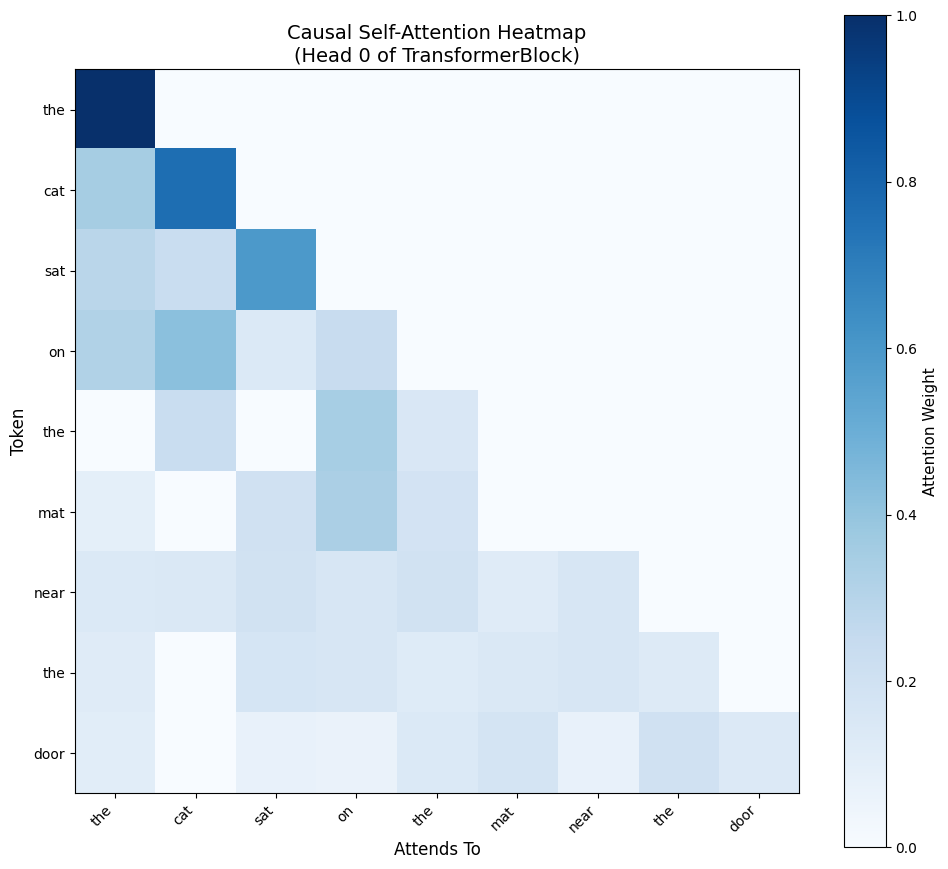

In [12]:
# Create attention visualization
torch.manual_seed(42)
np.random.seed(42)

# Sentence and tokenization
sentence = "the cat sat on the mat near the door"
tokens = sentence.split()  # Split on whitespace to get 9 tokens
print(f"\nTokens: {tokens}")
print(f"Number of tokens: {len(tokens)}")

# Create random embeddings
d_model_viz = 256
x_viz = torch.randn(1, len(tokens), d_model_viz)

# Create a smaller transformer block for visualization
block_viz = TransformerBlock(d_model_viz, num_heads=8, d_ff=1024)

# Forward pass with causal masking
output_viz, weights_viz = block_viz(x_viz, causal=True)

# Extract attention weights for head 0
w_head0 = weights_viz[0, 0].detach().numpy()  # Shape: (9, 9)

print(f"\nAttention weights shape: {w_head0.shape}")
print(f"Row sums (should be ~1.0): {w_head0.sum(axis=-1)}")

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(w_head0, cmap='Blues', vmin=0, vmax=1)

# Set token labels
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticklabels(tokens)

# Labels and title
ax.set_xlabel('Attends To', fontsize=12)
ax.set_ylabel('Token', fontsize=12)
ax.set_title('Causal Self-Attention Heatmap\n(Head 0 of TransformerBlock)', fontsize=14)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Attention Weight', fontsize=11)

plt.tight_layout()

# Save figure
plt_path = "/Users/tsheringwangpodorji/Documents/Year3 Sem II/DAM304/DAM304_AS2026_Practicals/practical_3/"
plt.savefig(plt_path + "attention_heatmap.png", dpi=100, bbox_inches='tight')
print(f"\n✓ Saved: attention_heatmap.png")
plt.show()

### Analysis: Understanding Causal Attention

**Q: In the causal heatmap, which cells should always be zero? Why?**

A: The **upper triangle** (above the diagonal) should always be zero. This is because causal masking ensures that each token can only attend to tokens that came *before* it in the sequence, plus itself. Mathematically, position i cannot attend to position j if j > i. We enforce this by setting scores to -∞ before softmax, making the attention weight exactly 0 after softmax.

In our 9×9 heatmap:
- Position 0 (first token) attends only to itself
- Position 1 attends to positions 0 and 1
- Position 8 (last token) attends to all 9 positions

This prevents "information leakage" from future tokens during language model training.

---

**Q: What does it mean if token 'cat' has a high attention weight towards 'mat'?**

A: It means that when computing the updated representation of 'cat', the model is heavily influenced by 'mat'. In the context of predicting the next token, if 'cat' places high attention on 'mat', the model is learning a semantic relationship: cats and mats are often related in language (e.g., "the cat sat on the mat"). This is learning about word co-occurrence patterns and semantic associations. By attending to semantically related words, the attention mechanism helps the model capture meaning and context.

---

**Q: Why do we use residual (skip) connections around both the attention and FFN sublayers?**

A: Residual connections provide several crucial benefits:

1. **Gradient Flow**: They create shortcuts for gradients during backpropagation. Without them, gradients would have to flow through all the transformations, potentially suffering from vanishing/exploding gradients in deep networks.

2. **Identity Mapping**: They preserve the original information and allow the network to learn subtle, incremental modifications rather than completely transforming the input from scratch. This makes learning more stable.

3. **Stability**: Residual connections help stabilize training, particularly in deep networks. They reduce the risk of the network "forgetting" important information from earlier layers.

4. **Architecture**: x = x + f(x) is more stable to train than x = f(x) because small perturbations to f(x) don't completely change the output.

## Summary: Expected Outputs Checklist

| # | Component | Expected Status |
|---|-----------|-----------------|
| 1 | Task 1: NumPy weights row sums | ✓ All rows sum to 1.0 (no mask). Upper triangle all 0.0 (causal mask) |
| 2 | Task 2: PyTorch output shape | ✓ (2, 6, 64) — batch=2, seq=6, d_v=64 |
| 3 | Task 3: Multi-Head output shape | ✓ (2, 10, 512) — same as input. ~1,048,576 parameters |
| 4 | Task 4: Transformer block output | ✓ (1, 8, 256) — same as input. Residual connections preserve shape |
| 5 | Attention heatmap | ✓ 9×9 heatmap saved. Upper triangle is dark. Token labels visible |

---